In [ ]:
!pip install -q scikit-learn pandas numpy matplotlib seaborn xgboost imbalanced-learn


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
RANDOM_STATE = 42


In [ ]:
from google.colab import drive
import pandas as pd


drive.mount('/content/drive')


file_path = '/content/drive/MyDrive/oral cancer/Patientwise_Labeled_Priority_Category 1.csv'  # replace with your actual path


df = pd.read_csv(file_path)


df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Patient ID,Age,Gender,Smoking,Chewing_Betel_Quid,Alcohol,Image Count,Result
0,R-01,63,M,No,No,No,3,OCA
1,R-02,17,F,No,No,No,8,Healthy
2,R-03,70,M,No,No,No,5,Healthy
3,R-04,45,M,No,No,No,5,Healthy
4,R-05,46,M,No,Yes,No,2,OCA


In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded.keys())))
df.head()

Saving Patientwise_Labeled_Priority_Category 1.csv to Patientwise_Labeled_Priority_Category 1.csv


,Patient ID,Age,Gender,Smoking,Chewing_Betel_Quid,Alcohol,Image Count,Result
0,R-01,63,M,No,No,No,3,OCA
1,R-02,17,F,No,No,No,8,Healthy
2,R-03,70,M,No,No,No,5,Healthy
3,R-04,45,M,No,No,No,5,Healthy
4,R-05,46,M,No,Yes,No,2,OCA


In [ ]:
# Normalize column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Convert object column values to lowercase to ensure consistent mapping
for col in ['gender', 'smoking', 'chewing_betel_quid', 'alcohol', 'result']:
    if col in df.columns and df[col].dtype == 'object':
        df[col] = df[col].str.strip().str.lower()


# Convert numeric
for col in ['age','image_count']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop missing rows (optional)
df = df.dropna().reset_index(drop=True)

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   patient_id          714 non-null    object
 1   age                 714 non-null    int64 
 2   gender              714 non-null    object
 3   smoking             714 non-null    object
 4   chewing_betel_quid  714 non-null    object
 5   alcohol             714 non-null    object
 6   image_count         714 non-null    int64 
 7   result              714 non-null    object
dtypes: int64(2), object(6)
memory usage: 44.8+ KB
None
  patient_id  age gender smoking chewing_betel_quid alcohol  image_count  \
0       R-01   63      m      no                 no      no            3   
1       R-02   17      f      no                 no      no            8   
2       R-03   70      m      no                 no      no            5   
3       R-04   45      m      no                 no     

In [ ]:
from scipy.stats import ttest_ind

age_cancer = df[df['result']==1]['age']
age_not_cancer = df[df['result']==0]['age']

t_stat, p_val = ttest_ind(age_cancer, age_not_cancer)
print('p-value:', p_val)

#p-value	Interpretation
#< 0.05	There is a significant difference in average age between cancer and non-cancer groups -> Age is likely related to cancer occurrence

p-value: nan


=== Chi-square Test Results ===

Gender vs Result → p-value: 0.21189
  ⚪ No significant association (Fail to reject H₀)

Smoking vs Result → p-value: 0.11778
  ⚪ No significant association (Fail to reject H₀)

Chewing_Betel_Quid vs Result → p-value: 0.00000
  🔹 Significant association (Reject H₀)

Alcohol vs Result → p-value: 0.00263
  🔹 Significant association (Reject H₀)


Summary Table:
              Variable        Chi2       p-value
2  chewing_betel_quid  146.541164  9.886352e-34
3             alcohol    9.049723  2.627346e-03
1             smoking    2.446540  1.177843e-01
0              gender    1.558433  2.118947e-01


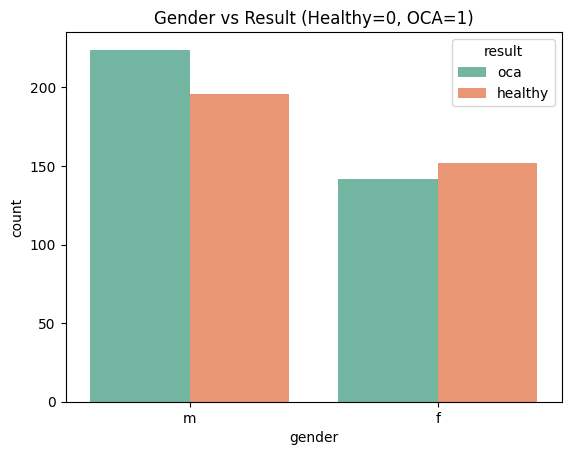

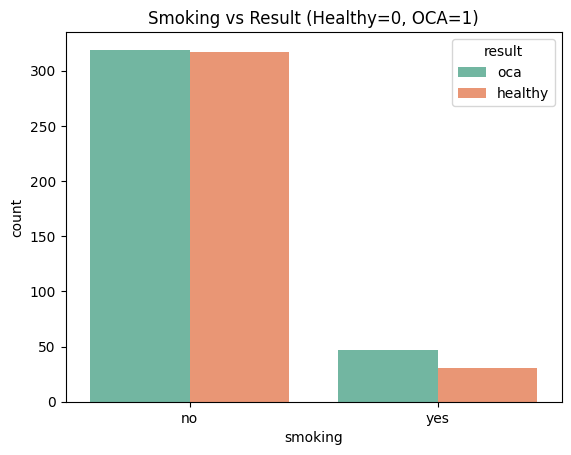

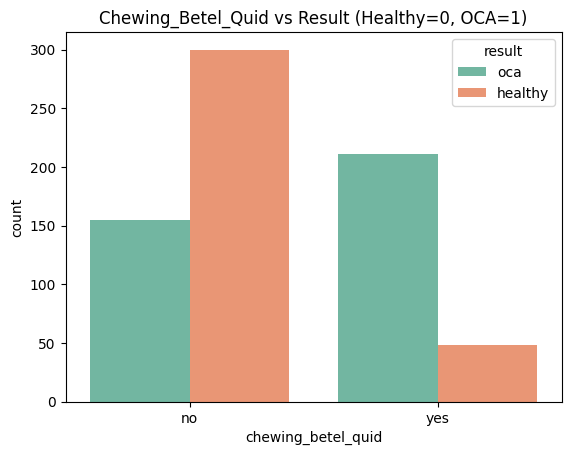

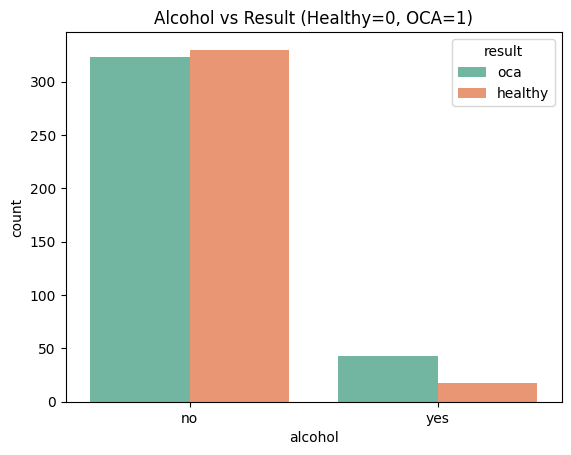

In [ ]:
print("=== Chi-square Test Results ===\n")
from scipy.stats import chi2_contingency

categorical_vars = ['gender', 'smoking', 'chewing_betel_quid', 'alcohol']
chi_results = []

for col in categorical_vars:
    contingency = pd.crosstab(df[col], df['result'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    chi_results.append({'Variable': col, 'Chi2': chi2, 'p-value': p})
    print(f"{col.title()} vs Result → p-value: {p:.5f}")
    if p < 0.05:
        print("  🔹 Significant association (Reject H₀)\n")
    else:
        print("  ⚪ No significant association (Fail to reject H₀)\n")

chi_df = pd.DataFrame(chi_results).sort_values(by='p-value')
print("\nSummary Table:\n", chi_df)

# Optional visualization
for col in categorical_vars:
    sns.countplot(x=col, hue='result', data=df, palette='Set2')
    plt.title(f"{col.title()} vs Result (Healthy=0, OCA=1)")
    plt.show()


In [ ]:
# ---------- 1. Drop the columns----------
cols_to_drop = [ 'smoking', 'image_count']
existing_to_drop = [c for c in cols_to_drop if c in df.columns]
if existing_to_drop:
    df = df.drop(columns=existing_to_drop)
    print(f"Dropped columns: {existing_to_drop}")
else:
    print("No smoking/image_count columns found to drop.")

print("Shape after dropping:", df.shape)

Dropped columns: ['smoking', 'image_count']
Shape after dropping: (714, 6)


In [ ]:
df

,patient_id,age,gender,chewing_betel_quid,alcohol,result
0,R-01,63,m,no,no,oca
1,R-02,17,f,no,no,healthy
2,R-03,70,m,no,no,healthy
3,R-04,45,m,no,no,healthy
4,R-05,46,m,yes,no,oca
...,...,...,...,...,...,...
709,N-355,30,m,yes,no,oca
710,N-356,22,m,no,no,healthy
711,N-357,30,f,no,no,oca
712,N-358,68,f,yes,no,oca


In [ ]:
df['result'] = df['result'].map({'healthy': 0, 'oca': 1})


In [ ]:
df['result']

,result
0,1
1,0
2,0
3,0
4,1
...,...
709,1
710,0
711,1
712,1


In [ ]:

#  Split Features & Target

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop(columns=['result'])
y = df['result']


# 1. First split: Train (70%) + Temp (30%)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)


# 2. Split Temp into Validation (10%) + Test (20%)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=(20/30),   # = 0.6667
    stratify=y_temp,
    random_state=RANDOM_STATE
)

In [ ]:
# STEP 6 – Keep patient IDs separate (for later prediction)

test_patient_ids = X_test['patient_id']  # keep IDs for mapping predictions
val_patient_ids = X_val['patient_id']    # optional, if needed
train_patient_ids = X_train['patient_id'] # optional, if needed

# Drop patient_id from features before feeding into model
X_train_features = X_train.drop(columns=['patient_id'])
X_val_features = X_val.drop(columns=['patient_id'])
X_test_features = X_test.drop(columns=['patient_id'])

In [ ]:
X_train_features.head()

,age,gender,chewing_betel_quid,alcohol
44,52,f,no,no
239,48,m,yes,no
398,21,m,yes,yes
689,73,m,no,no
558,21,m,no,no


In [ ]:
# Binary mappings
yes_no_map = {'no': 0, 'yes': 1}
gender_map = {'f': 0, 'm': 1}


In [ ]:
for df_part in [X_train_features, X_val_features, X_test_features]:

    # Gender
    if 'gender' in df_part.columns:
        df_part['gender'] = df_part['gender'].map(gender_map)

    # Yes / No variables
    for col in ['smoking', 'chewing_betel_quid', 'alcohol']:
        if col in df_part.columns:
            df_part[col] = df_part[col].map(yes_no_map)


In [ ]:
X_train_features.head()

,age,gender,chewing_betel_quid,alcohol
44,52,0,0,0
239,48,1,1,0
398,21,1,1,1
689,73,1,0,0
558,21,1,0,0


In [ ]:
y_train.head()

,result
44,healthy
239,oca
398,healthy
689,oca
558,healthy


In [ ]:
X_train_features.head()

,age,gender,chewing_betel_quid,alcohol
44,52,f,no,no
239,48,m,yes,no
398,21,m,yes,yes
689,73,m,no,no
558,21,m,no,no


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Categorical & numeric columns
categorical_cols = ['gender', 'chewing_betel_quid', 'alcohol']
numeric_cols = ['age']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)


In [ ]:
X_train_features = preprocessor.fit_transform(X_train_features)
X_val_features   = preprocessor.transform(X_val_features)
X_test_features  = preprocessor.transform(X_test_features)


In [ ]:
X_train_features.head()

,age,chewing_betel_quid,alcohol
44,0.202252,0,0
239,-0.007242,1,0
398,-1.421324,1,1
689,1.302093,0,0
558,-1.421324,0,0


In [ ]:
# After your splitting code

print("Total patients:", len(df))

print("== Overall split counts ==")
print("Train:", len(y_train))
print("Validation:", len(y_val))
print("Test:", len(y_test))

print("\n== Split by class (result) ==")
print("Train class distribution:")
print(y_train.value_counts())
print("\nValidation class distribution:")
print(y_val.value_counts())
print("\nTest class distribution:")
print(y_test.value_counts())


Total patients: 714
== Overall split counts ==
Train: 499
Validation: 71
Test: 144

== Split by class (result) ==
Train class distribution:
result
1    256
0    243
Name: count, dtype: int64

Validation class distribution:
result
1    36
0    35
Name: count, dtype: int64

Test class distribution:
result
1    74
0    70
Name: count, dtype: int64


In [ ]:
# Scale only the 'age' column
scaler = StandardScaler()
numeric_cols = ['age']    # only age now

for col in numeric_cols:
    if col in X_train.columns:
        # Fit on train
        X_train_features[col] = scaler.fit_transform(X_train_features[[col]])

        # Transform val and test
        X_val_features[col] = scaler.transform(X_val_features[[col]])
        X_test_features[col] = scaler.transform(X_test_features[[col]])

In [ ]:
X_train_features.head()

,age,chewing_betel_quid,alcohol
44,0.202252,0,0
239,-0.007242,1,0
398,-1.421324,1,1
689,1.302093,0,0
558,-1.421324,0,0


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


# Train Logistic Regression on TRAIN data

lr = LogisticRegression(
    max_iter=200,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

lr.fit(X_train_features, y_train)
#Evaluate Training Accuracy

y_train_pred = lr.predict(X_train_features)
train_acc = accuracy_score(y_train, y_train_pred)

print("=== Training Classification Report ===")
print(classification_report(y_train, y_train_pred))


# Validate on VALIDATION dataset

y_val_pred = lr.predict(X_val_features)
print("=== Validation Performance (Logistic Regression) ===")
print(classification_report(y_val, y_val_pred))


# Final TEST evaluation

y_test_pred_lr = lr.predict(X_test_features)
print("=== Test Performance (Logistic Regression) ===")
print(classification_report(y_test, y_test_pred_lr))

=== Training Classification Report ===
              precision    recall  f1-score   support

           0       0.64      0.85      0.73       243
           1       0.79      0.55      0.65       256

    accuracy                           0.70       499
   macro avg       0.72      0.70      0.69       499
weighted avg       0.72      0.70      0.69       499

=== Validation Performance (Logistic Regression) ===
              precision    recall  f1-score   support

           0       0.70      0.89      0.78        35
           1       0.85      0.64      0.73        36

    accuracy                           0.76        71
   macro avg       0.78      0.76      0.76        71
weighted avg       0.78      0.76      0.76        71

=== Test Performance (Logistic Regression) ===
              precision    recall  f1-score   support

           0       0.69      0.90      0.78        70
           1       0.87      0.62      0.72        74

    accuracy                           0.76

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


# Train Random Forest on TRAIN data

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

rf.fit(X_train_features, y_train)


# Evaluate Training Set

y_train_pred = rf.predict(X_train_features)
train_acc = accuracy_score(y_train, y_train_pred)
print("=== Training Accuracy (Default Threshold 0.50) ===", round(train_acc, 3))
print("=== Training Classification Report ===")
print(classification_report(y_train, y_train_pred))


# Evaluate Validation Set

y_val_pred = rf.predict(X_val_features)
val_acc = accuracy_score(y_val, y_val_pred)
print("\n=== Validation Accuracy (Default Threshold 0.50) ===", round(val_acc, 3))
print("=== Validation Classification Report ===")
print(classification_report(y_val, y_val_pred))


# Evaluate Test Set

y_test_pred = rf.predict(X_test_features)
test_acc = accuracy_score(y_test, y_test_pred)
print("\n=== Test Accuracy (Default Threshold 0.50) ===", round(test_acc, 3))
print("=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred))


=== Training Accuracy (Default Threshold 0.50) === 0.784
=== Training Classification Report ===
              precision    recall  f1-score   support

           0       0.76      0.82      0.79       243
           1       0.81      0.75      0.78       256

    accuracy                           0.78       499
   macro avg       0.79      0.78      0.78       499
weighted avg       0.79      0.78      0.78       499


=== Validation Accuracy (Default Threshold 0.50) === 0.62
=== Validation Classification Report ===
              precision    recall  f1-score   support

           0       0.61      0.66      0.63        35
           1       0.64      0.58      0.61        36

    accuracy                           0.62        71
   macro avg       0.62      0.62      0.62        71
weighted avg       0.62      0.62      0.62        71


=== Test Accuracy (Default Threshold 0.50) === 0.715
=== Test Classification Report ===
              precision    recall  f1-score   support

      

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

rf = RandomForestClassifier(
    n_estimators=400,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

param_grid = {
    'max_depth': [6, 8, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


#  Hyperparameter Tuning with 5-fold CV

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_features, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV Score:", round(grid_search.best_score_, 3))




best_rf = grid_search.best_estimator_
best_rf.fit(X_train_features, y_train)


y_train_pred = best_rf.predict(X_train_features)
train_acc = accuracy_score(y_train, y_train_pred)
print("\n=== Training Accuracy ===", round(train_acc, 3))
print("=== Training Classification Report ===")
print(classification_report(y_train, y_train_pred))


y_val_pred = best_rf.predict(X_val_features)
val_acc = accuracy_score(y_val, y_val_pred)
print("\n=== Validation Accuracy ===", round(val_acc, 3))
print("=== Validation Classification Report ===")
print(classification_report(y_val, y_val_pred))


y_test_pred_rf = best_rf.predict(X_test_features)
test_acc = accuracy_score(y_test, y_test_pred_rf)
print("\n=== Test Accuracy ===", round(test_acc, 3))
print("=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred_rf))


threshold = 0.40
y_test_prob = best_rf.predict_proba(X_test_features)[:,1]
y_test_adj = (y_test_prob > threshold).astype(int)
print(f"\n=== Test Performance with Threshold {threshold} ===")
print(classification_report(y_test, y_test_adj))


Best Hyperparameters: {'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best CV Score: 0.657

=== Training Accuracy === 0.735
=== Training Classification Report ===
              precision    recall  f1-score   support

           0       0.71      0.77      0.74       243
           1       0.76      0.70      0.73       256

    accuracy                           0.74       499
   macro avg       0.74      0.74      0.74       499
weighted avg       0.74      0.74      0.74       499


=== Validation Accuracy === 0.676
=== Validation Classification Report ===
              precision    recall  f1-score   support

           0       0.67      0.69      0.68        35
           1       0.69      0.67      0.68        36

    accuracy                           0.68        71
   macro avg       0.68      0.68      0.68        71
weighted avg       0.68      0.68      0.68        71


=== Test Accuracy === 0.708
=== Test Classification Report ===
              precision   

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report


xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric='logloss'
)

xgb.fit(X_train_features, y_train)

y_train_pred = xgb.predict(X_train_features)
train_acc = accuracy_score(y_train, y_train_pred)
print("=== Training Accuracy ===", round(train_acc, 3))
print("=== Training Classification Report ===")
print(classification_report(y_train, y_train_pred))


y_val_pred = xgb.predict(X_val_features)
print("=== Validation Performance (XGBoost) ===")
print(classification_report(y_val, y_val_pred))


y_test_pred = xgb.predict(X_test_features)
print("\n=== Test Performance (XGBoost) ===")
print(classification_report(y_test, y_test_pred))


=== Training Accuracy === 0.747
=== Training Classification Report ===
              precision    recall  f1-score   support

           0       0.73      0.76      0.75       243
           1       0.76      0.73      0.75       256

    accuracy                           0.75       499
   macro avg       0.75      0.75      0.75       499
weighted avg       0.75      0.75      0.75       499

=== Validation Performance (XGBoost) ===
              precision    recall  f1-score   support

           0       0.66      0.66      0.66        35
           1       0.67      0.67      0.67        36

    accuracy                           0.66        71
   macro avg       0.66      0.66      0.66        71
weighted avg       0.66      0.66      0.66        71


=== Test Performance (XGBoost) ===
              precision    recall  f1-score   support

           0       0.69      0.73      0.71        70
           1       0.73      0.69      0.71        74

    accuracy                      

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score


#  Define XGBoost classifier
xgb = XGBClassifier(
    random_state=RANDOM_STATE,
    use_label_encoder=False,
    eval_metric='logloss'
)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}
#  Grid Search with 5-fold CV on training set
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    verbose=1,
    n_jobs=-1
)
grid_search.fit(X_train_features, y_train)



print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV F1 Score:", round(grid_search.best_score_, 3))



best_xgb = grid_search.best_estimator_

# Training set evaluation
y_train_pred = best_xgb.predict(X_train_features)
train_acc = accuracy_score(y_train, y_train_pred)
print("\n=== Training Accuracy ===", round(train_acc, 3))
print("=== Training Classification Report ===")
print(classification_report(y_train, y_train_pred))

# Validation set evaluation
y_val_pred = best_xgb.predict(X_val_features)
val_acc = accuracy_score(y_val, y_val_pred)
print("\n=== Validation Accuracy ===", round(val_acc, 3))
print("=== Validation Classification Report ===")
print(classification_report(y_val, y_val_pred))

# Test set evaluation
y_test_pred_xgb = best_xgb.predict(X_test_features)
test_acc = accuracy_score(y_test, y_test_pred_xgb)
print("\n=== Test Accuracy ===", round(test_acc, 3))
print("=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred_xgb))


threshold = 0.40
y_test_prob = best_xgb.predict_proba(X_test_features)[:,1]
y_test_adj = (y_test_prob > threshold).astype(int)
print(f"\n=== Test Performance with Threshold {threshold} ===")
print(classification_report(y_test, y_test_adj))


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Best Hyperparameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.9}
Best CV F1 Score: 0.667

=== Training Accuracy === 0.739
=== Training Classification Report ===
              precision    recall  f1-score   support

           0       0.71      0.77      0.74       243
           1       0.77      0.71      0.74       256

    accuracy                           0.74       499
   macro avg       0.74      0.74      0.74       499
weighted avg       0.74      0.74      0.74       499


=== Validation Accuracy === 0.676
=== Validation Classification Report ===
              precision    recall  f1-score   support

           0       0.67      0.69      0.68        35
           1       0.69      0.67      0.68        36

    accuracy                           0.68        71
   macro avg       0.68      0.68      0.68        71
weighted avg       0.68      0.68      0

In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score


# STEP 1 – Define LightGBM Classifier
lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)
# STEP 2 – Train on TRAIN data

lgbm.fit(X_train_features, y_train)



y_train_pred = lgbm.predict(X_train_features)
train_acc = accuracy_score(y_train, y_train_pred)
print("=== Training Accuracy ===", round(train_acc, 3))
print("=== Training Classification Report ===")
print(classification_report(y_train, y_train_pred))


y_val_pred = lgbm.predict(X_val_features)
val_acc = accuracy_score(y_val, y_val_pred)
print("\n=== Validation Accuracy ===", round(val_acc, 3))
print("=== Validation Classification Report ===")
print(classification_report(y_val, y_val_pred))


# STEP 5 – Evaluate on TEST data
y_test_pred_lgbm = lgbm.predict(X_test_features)
test_acc = accuracy_score(y_test, y_test_pred_lgbm)
print("\n=== Test Accuracy ===", round(test_acc, 3))
print("=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred_lgbm))


threshold = 0.40
y_test_prob = lgbm.predict_proba(X_test_features)[:, 1]
y_test_adj = (y_test_prob > threshold).astype(int)
print(f"\n=== Test Performance with Threshold {threshold} ===")
print(classification_report(y_test, y_test_adj))

[LightGBM] [Info] Number of positive: 256, number of negative: 243
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000733 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 74
[LightGBM] [Info] Number of data points in the train set: 499, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

In [ ]:

#  Define LightGBM classifier
lgb_model = lgb.LGBMClassifier(objective='binary', random_state=42)

# Set GridSearchCV parameters
param_grid = {
    'num_leaves': [15, 31, 63],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0]
}

#  GridSearchCV
grid = GridSearchCV(estimator=lgb_model,
                    param_grid=param_grid,
                    scoring='f1',          # optimize F1-score
                    cv=5,
                    n_jobs=-1,
                    verbose=2)

grid.fit(X_train_features, y_train)


print("Best Hyperparameters:", grid.best_params_)
print("Best CV F1 Score:", grid.best_score_)


best_model = grid.best_estimator_

def evaluate_model(model, X, y, threshold=0.5):
    y_proba = model.predict_proba(X)[:,1]
    y_pred = (y_proba >= threshold).astype(int)
    print(f"Accuracy: {accuracy_score(y, y_pred):.3f}")
    print(classification_report(y, y_pred))

print("=== Training Performance ===")
evaluate_model(best_model, X_train_features, y_train)

print("=== Validation Performance ===")
evaluate_model(best_model, X_val_features, y_val)

print("=== Test Performance (Default Threshold 0.5) ===")
evaluate_model(best_model, X_test_features, y_test)

print("=== Test Performance (Threshold 0.4 for OCA recall) ===")
evaluate_model(best_model, X_test_features, y_test, threshold=0.4)

Fitting 5 folds for each of 729 candidates, totalling 3645 fits
[LightGBM] [Info] Number of positive: 256, number of negative: 243
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000074 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 74
[LightGBM] [Info] Number of data points in the train set: 499, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.513026 -> initscore=0.052116
[LightGBM] [Info] Start training from score 0.052116
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Wa

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score


RANDOM_STATE = 42


gb = GradientBoostingClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    max_features=0.8,
    random_state=RANDOM_STATE
)
# Fit the model

gb.fit(X_train_features, y_train)

# Training Performance
y_train_pred = gb.predict(X_train_features)
print("=== Training Classification Report (Gradient Boosting) ===")
print(classification_report(y_train, y_train_pred))


y_val_pred = gb.predict(X_val_features)
print("=== Validation Performance (Gradient Boosting) ===")
print(classification_report(y_val, y_val_pred))


y_test_pred = gb.predict(X_test_features)
print("=== Test Performance (Gradient Boosting) ===")
print(classification_report(y_test, y_test_pred))


=== Training Classification Report (Gradient Boosting) ===
              precision    recall  f1-score   support

           0       0.75      0.79      0.77       243
           1       0.79      0.76      0.77       256

    accuracy                           0.77       499
   macro avg       0.77      0.77      0.77       499
weighted avg       0.77      0.77      0.77       499

=== Validation Performance (Gradient Boosting) ===
              precision    recall  f1-score   support

           0       0.60      0.60      0.60        35
           1       0.61      0.61      0.61        36

    accuracy                           0.61        71
   macro avg       0.61      0.61      0.61        71
weighted avg       0.61      0.61      0.61        71

=== Test Performance (Gradient Boosting) ===
              precision    recall  f1-score   support

           0       0.68      0.73      0.70        70
           1       0.72      0.68      0.70        74

    accuracy               

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score


RANDOM_STATE = 42

# Train Gradient Boosting on TRAIN data
gb = GradientBoostingClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    max_features='sqrt',
    validation_fraction=0.1,
    n_iter_no_change=50,
    random_state=RANDOM_STATE
)

# Fit the model
gb.fit(X_train_features, y_train)
# Evaluate Training Performance

y_train_pred = gb.predict(X_train_features)
train_acc = accuracy_score(y_train, y_train_pred)
print("=== Training Classification Report (Gradient Boosting) ===")
print(classification_report(y_train, y_train_pred))


y_val_pred = gb.predict(X_val_features)
print("=== Validation Performance (Gradient Boosting) ===")
print(classification_report(y_val, y_val_pred))


y_test_pred_gb = gb.predict(X_test_features)
print("=== Test Performance (Gradient Boosting) ===")
print(classification_report(y_test, y_test_pred_gb))


=== Training Classification Report (Gradient Boosting) ===
              precision    recall  f1-score   support

           0       0.66      0.84      0.74       243
           1       0.80      0.59      0.68       256

    accuracy                           0.71       499
   macro avg       0.73      0.71      0.71       499
weighted avg       0.73      0.71      0.71       499

=== Validation Performance (Gradient Boosting) ===
              precision    recall  f1-score   support

           0       0.71      0.86      0.78        35
           1       0.83      0.67      0.74        36

    accuracy                           0.76        71
   macro avg       0.77      0.76      0.76        71
weighted avg       0.77      0.76      0.76        71

=== Test Performance (Gradient Boosting) ===
              precision    recall  f1-score   support

           0       0.67      0.83      0.74        70
           1       0.79      0.61      0.69        74

    accuracy               

In [ ]:
from sklearn.neighbors import KNeighborsClassifier


# Train KNN on TRAIN data

knn = KNeighborsClassifier(
    n_neighbors=10,
    weights='uniform'
)

knn.fit(X_train_features, y_train)

# Evaluate Training Accuracy
y_train_pred = knn.predict(X_train_features)
print("=== Training Classification Report (KNN) ===")
print(classification_report(y_train, y_train_pred))


y_val_pred = knn.predict(X_val_features)
print("=== Validation Performance (KNN) ===")
print(classification_report(y_val, y_val_pred))


y_test_pred_knn = knn.predict(X_test_features)
print("=== Test Performance (KNN) ===")
print(classification_report(y_test, y_test_pred_knn))


=== Training Classification Report (KNN) ===
              precision    recall  f1-score   support

           0       0.69      0.77      0.73       243
           1       0.75      0.67      0.71       256

    accuracy                           0.72       499
   macro avg       0.72      0.72      0.72       499
weighted avg       0.72      0.72      0.72       499

=== Validation Performance (KNN) ===
              precision    recall  f1-score   support

           0       0.68      0.74      0.71        35
           1       0.73      0.67      0.70        36

    accuracy                           0.70        71
   macro avg       0.71      0.70      0.70        71
weighted avg       0.71      0.70      0.70        71

=== Test Performance (KNN) ===
              precision    recall  f1-score   support

           0       0.68      0.77      0.72        70
           1       0.75      0.66      0.71        74

    accuracy                           0.72       144
   macro avg   

In [ ]:
from sklearn.svm import SVC


# Train SVM on TRAIN data

svm = SVC(
    kernel='rbf',
    C=1.0,
    probability=True,
    random_state=RANDOM_STATE
)

svm.fit(X_train_features, y_train)

# Evaluate Training Accuracy
y_train_pred = svm.predict(X_train_features)
print("=== Training Classification Report (SVM) ===")
print(classification_report(y_train, y_train_pred))


# Validate on VALIDATION dataset
y_val_pred = svm.predict(X_val_features)
print("=== Validation Performance (SVM) ===")
print(classification_report(y_val, y_val_pred))


y_test_pred_svm = svm.predict(X_test_features)
print("=== Test Performance (SVM) ===")
print(classification_report(y_test, y_test_pred_svm))


=== Training Classification Report (SVM) ===
              precision    recall  f1-score   support

           0       0.65      0.84      0.74       243
           1       0.79      0.58      0.67       256

    accuracy                           0.71       499
   macro avg       0.72      0.71      0.70       499
weighted avg       0.72      0.71      0.70       499

=== Validation Performance (SVM) ===
              precision    recall  f1-score   support

           0       0.71      0.86      0.78        35
           1       0.83      0.67      0.74        36

    accuracy                           0.76        71
   macro avg       0.77      0.76      0.76        71
weighted avg       0.77      0.76      0.76        71

=== Test Performance (SVM) ===
              precision    recall  f1-score   support

           0       0.68      0.84      0.75        70
           1       0.81      0.62      0.70        74

    accuracy                           0.73       144
   macro avg   

In [ ]:
!pip install catboost
from catboost import CatBoostClassifier


# Train CatBoost on TRAIN data
cat = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=3,
    verbose=0,
    random_state=RANDOM_STATE
)

cat.fit(X_train_features, y_train)

# Evaluate Training Accuracy
y_train_pred = cat.predict(X_train_features)
print("=== Training Classification Report (CatBoost) ===")
print(classification_report(y_train, y_train_pred))

y_val_pred = cat.predict(X_val_features)
print("=== Validation Performance (CatBoost) ===")
print(classification_report(y_val, y_val_pred))


y_test_pred_cat = cat.predict(X_test_features)
print("=== Test Performance (CatBoost) ===")
print(classification_report(y_test, y_test_pred_cat))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.7 MB/s eta 0:00:00
=== Training Classification Report (CatBoost) ===
              precision    recall  f1-score   support

           0       0.72      0.81      0.76       243
           1       0.79      0.70      0.74       256

    accuracy                           0.75       499
   macro avg       0.75      0.75      0.75       499
weighted avg       0.76      0.75      0.75       499

=== Validation Performance (CatBoost) ===
              precision    recall  f1-score   support

           0       0.68      0.71      0.69        35
           1       0.71      0.67      0.69        36

    accuracy                           0.69        71
   macro avg       0.69      0.69      0.69        71
weighted avg       0.69      0.69      0.69        71

=== Test Performance (CatBoost) ===
              precision    recall  f1-score   support

           0       0.70      0.76      0.73        70
           1       0.75      0.

=== Model Comparison ===
                 Model  Accuracy  Precision  Recall  F1-Score
3             LightGBM     0.750      0.797   0.689     0.739
0  Logistic Regression     0.757      0.868   0.622     0.724
4             CatBoost     0.722      0.750   0.689     0.718
1        Random Forest     0.708      0.729   0.689     0.708
6  K-Nearest Neighbors     0.715      0.754   0.662     0.705
2              XGBoost     0.708      0.735   0.676     0.704
7                  SVM     0.729      0.807   0.622     0.702
5    Gradient Boosting     0.715      0.789   0.608     0.687


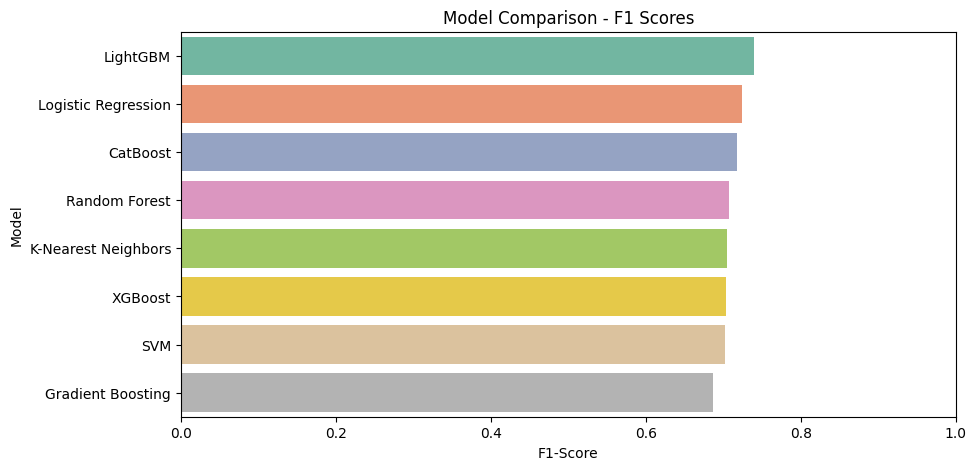

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Create a dictionary of all models and their predictions
models = {
    "Logistic Regression": y_test_pred_lr,
    "Random Forest": y_test_pred_rf,
    "XGBoost": y_test_pred_xgb,
    "LightGBM": y_test_pred_lgbm,
    "CatBoost": y_test_pred_cat,
    "Gradient Boosting": y_test_pred_gb,
    "K-Nearest Neighbors": y_test_pred_knn,
    "SVM":y_test_pred_svm,
    "CatBoost": y_test_pred_cat
}

# Initialize an empty list to store results
results = []

# Calculate metrics for each model
for model_name, y_pred in models.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        "Model": model_name,
        "Accuracy": round(acc, 3),
        "Precision": round(prec, 3),
        "Recall": round(rec, 3),
        "F1-Score": round(f1, 3)
    })

# Convert to DataFrame for display
results_df = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print("=== Model Comparison ===")
print(results_df)

# Optional: Plot a bar chart for F1-Scores
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.barplot(x="F1-Score", y="Model", data=results_df, palette="Set2")
plt.title("Model Comparison - F1 Scores")
plt.xlim(0,1)
plt.show()

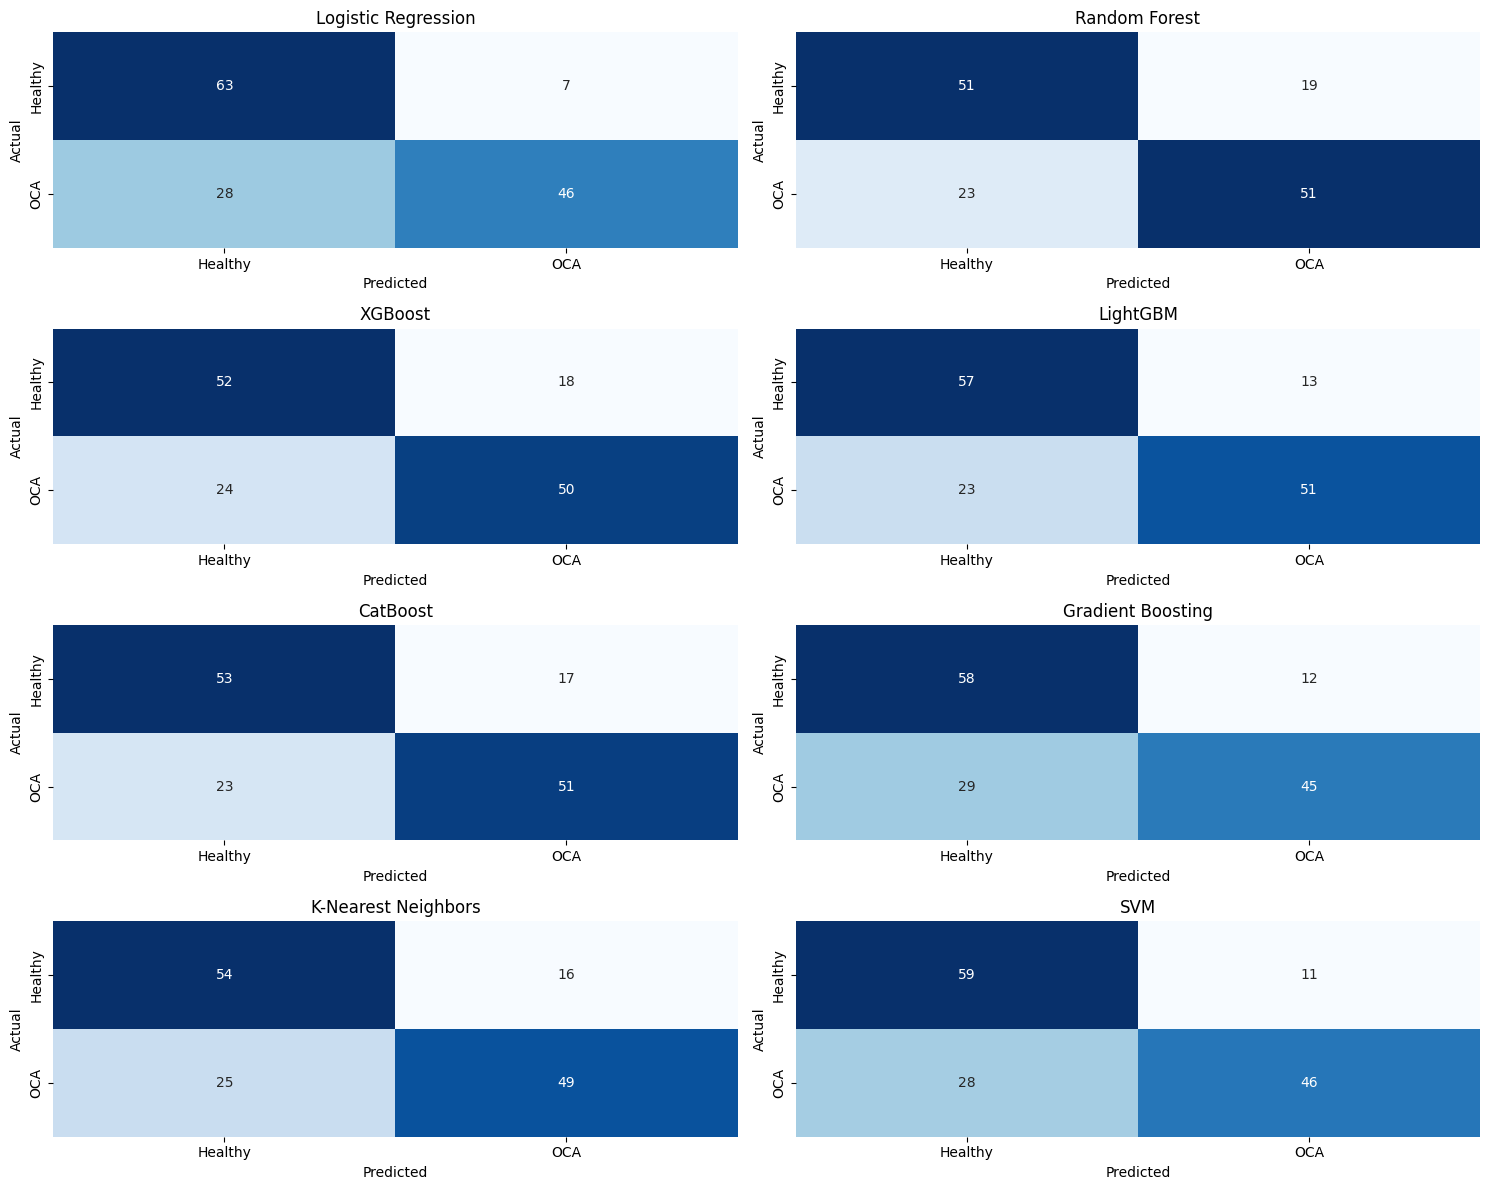

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Dictionary of all models and their predictions
models = {
    "Logistic Regression": y_test_pred_lr,
    "Random Forest": y_test_pred_rf,
    "XGBoost": y_test_pred_xgb,
    "LightGBM": y_test_pred_lgbm,
    "CatBoost": y_test_pred_cat,
    "Gradient Boosting": y_test_pred_gb,
    "K-Nearest Neighbors": y_test_pred_knn,
    "SVM":y_test_pred_svm,
    "CatBoost": y_test_pred_cat
}

# Plot confusion matrices
plt.figure(figsize=(15, 12))
for i, (model_name, y_pred) in enumerate(models.items(), 1):
    cm = confusion_matrix(y_test, y_pred)
    plt.subplot(4, 2, i)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Healthy', 'OCA'], yticklabels=['Healthy', 'OCA'])
    plt.title(model_name)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
plt.tight_layout()
plt.show()


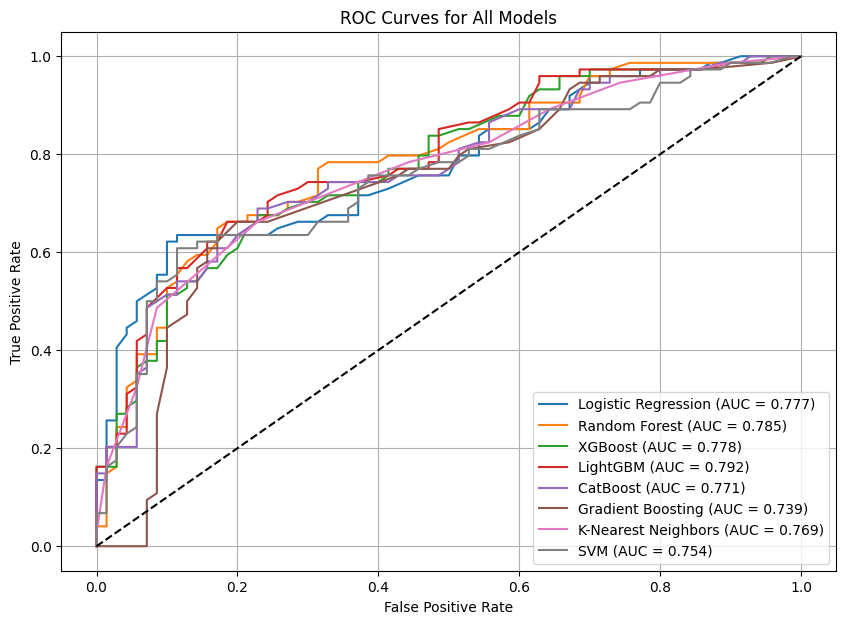

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Dictionary of trained models (NOT predictions)
models = {
     "Logistic Regression": lr,
    "Random Forest": best_rf,
    "XGBoost": best_xgb,
    "LightGBM": best_model,
    "CatBoost": cat,
    "Gradient Boosting": gb,
    "K-Nearest Neighbors": knn,
    "SVM": svm
}

plt.figure(figsize=(10, 7))

for model_name, model in models.items():

    # SVM needs probability=True OR use decision_function
    if model_name == "SVM":
        try:
            y_prob = model.predict_proba(X_test_features)[:, 1]
        except:
            y_prob = model.decision_function(X_test_features)
    else:
        y_prob = model.predict_proba(X_test_features)[:, 1]

    # Compute ROC
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})")


# Plot formatting
plt.plot([0, 1], [0, 1], "k--")  # Diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for All Models")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
# Predict class labels (0/1)
y_test_pred_lgbm = lgbm.predict(X_test_features)

# Predict class probabilities (for both classes)
y_test_proba_lgbm = lgbm.predict_proba(X_test_features)

In [ ]:
def predict_meta_single(index):
    sample = X_test.iloc[[index]]       # keep 2D shape
    true_label = y_test.iloc[index]

    pred_class = lgbm.predict(sample)[0]
    pred_prob = lgbm.predict_proba(sample)[0][1]   # class 1 probability

    print(f"True: {true_label} | Pred: {pred_class}")
    print(f"Probability: {round(pred_prob, 3)}")

    return true_label, pred_class, pred_prob


In [ ]:
predict_meta_single(130)


True: 1 | Pred: 1
Probability: 0.627


(np.int64(1), np.int64(1), np.float64(0.6274875720376948))

In [ ]:
predict_meta_single(30)


True: 1 | Pred: 1
Probability: 0.888


(np.int64(1), np.int64(1), np.float64(0.8879593982382059))

In [ ]:
predict_meta_single(25)


True: 1 | Pred: 1
Probability: 0.873


(np.int64(1), np.int64(1), np.float64(0.87321797122911))

In [ ]:
predict_meta_single(99)

True: 0 | Pred: 0
Probability: 0.417


(np.int64(0), np.int64(0), np.float64(0.41673503644274695))

In [ ]:
def predict_meta_by_patient(patient_id):
    # Find the row in X_test corresponding to this patient_id
    # The patient_id is now expected to be an index from X_test
    if patient_id not in X_test.index:
        print(f"No patient found with ID (index): {patient_id}")
        return None

    sample = X_test.loc[[patient_id]]

    # Keep 2D shape
    true_label = y_test.loc[sample.index[0]]
    pred_class = lgbm.predict(sample)[0]
    pred_prob = lgbm.predict_proba(sample)[0][1]   # class 1 probability

    print(f"Patient ID (index): {patient_id} | True: {true_label} | Pred: {pred_class}")
    print(f"Probability of Class 1: {round(pred_prob, 3)}")

    return true_label, pred_class, pred_prob

In [ ]:
all_patient_probs = []
for pid in X_test.index: # Iterate over the index of X_test
    result = predict_meta_by_patient(pid)
    all_patient_probs.append((pid, result[2]))  # store patient_id and class 1 probability

# Convert to DataFrame if needed
proba_df = pd.DataFrame(all_patient_probs, columns=['patient_id', 'class1_proba'])
proba_df.head()

Patient ID (index): 330 | True: 1 | Pred: 1
Probability of Class 1: 0.849
Patient ID (index): 336 | True: 1 | Pred: 1
Probability of Class 1: 0.564
Patient ID (index): 418 | True: 0 | Pred: 0
Probability of Class 1: 0.464
Patient ID (index): 474 | True: 1 | Pred: 0
Probability of Class 1: 0.316
Patient ID (index): 674 | True: 1 | Pred: 1
Probability of Class 1: 0.748
Patient ID (index): 518 | True: 1 | Pred: 0
Probability of Class 1: 0.216
Patient ID (index): 509 | True: 1 | Pred: 1
Probability of Class 1: 0.789
Patient ID (index): 280 | True: 1 | Pred: 1
Probability of Class 1: 0.888
Patient ID (index): 271 | True: 0 | Pred: 0
Probability of Class 1: 0.105
Patient ID (index): 528 | True: 0 | Pred: 0
Probability of Class 1: 0.417
Patient ID (index): 344 | True: 0 | Pred: 0
Probability of Class 1: 0.389
Patient ID (index): 369 | True: 0 | Pred: 0
Probability of Class 1: 0.352
Patient ID (index): 235 | True: 1 | Pred: 1
Probability of Class 1: 0.564
Patient ID (index): 374 | True: 0 | Pr

,patient_id,class1_proba
0,330,0.848583
1,336,0.564005
2,418,0.463672
3,474,0.315913
4,674,0.747639


In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, accuracy_score

# =======================================================
# STEP 1 – Define LightGBM Classifier
# =======================================================
lgbm = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

# =======================================================
# STEP 2 – Train on TRAIN FEATURES ONLY
# =======================================================
lgbm.fit(X_train_features, y_train)

# =======================================================
# STEP 3 – Evaluate on TRAIN data
# =======================================================
y_train_pred = lgbm.predict(X_train_features)
train_acc = accuracy_score(y_train, y_train_pred)
print("=== Training Accuracy ===", round(train_acc, 3))
print("=== Training Classification Report ===")
print(classification_report(y_train, y_train_pred))

# =======================================================
# STEP 4 – Evaluate on VALIDATION data
# =======================================================
y_val_pred = lgbm.predict(X_val_features)
val_acc = accuracy_score(y_val, y_val_pred)
print("\n=== Validation Accuracy ===", round(val_acc, 3))
print("=== Validation Classification Report ===")
print(classification_report(y_val, y_val_pred))

# =======================================================
# STEP 5 – Evaluate on TEST data
# =======================================================
y_test_pred_lgbm = lgbm.predict(X_test_features)
test_acc = accuracy_score(y_test, y_test_pred_lgbm)
print("\n=== Test Accuracy ===", round(test_acc, 3))
print("=== Test Classification Report ===")
print(classification_report(y_test, y_test_pred_lgbm))

# =======================================================
# STEP 6 – Adjust Threshold (Optional)
# =======================================================
threshold = 0.40
y_test_prob = lgbm.predict_proba(X_test_features)[:, 1] # Select only class 1 probabilities
y_test_adj = (y_test_prob > threshold).astype(int)

print(f"\n=== Test Performance with Threshold {threshold} ===")
print(classification_report(y_test, y_test_adj))

[LightGBM] [Info] Number of positive: 256, number of negative: 243
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000198 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 74
[LightGBM] [Info] Number of data points in the train set: 499, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[

In [ ]:
# === Predict probabilities for both classes ===
test_proba = lgbm.predict_proba(X_test_features)

# === Create final probability dataframe ===
proba_df = pd.DataFrame({
    'patient_id': test_patient_ids,      # patient IDs for test set
    'true_label': y_test.values,         # actual labels
    'pred_class': y_test_pred_lgbm,      # predicted 0/1
    'class0_proba': test_proba[:, 0],    # probability of Class 0
    'class1_proba': test_proba[:, 1]     # probability of Class 1
})

# Show the first few rows
proba_df.head()


,patient_id,true_label,pred_class,class0_proba,class1_proba
330,S-147,1,1,0.151417,0.848583
336,S-154,1,1,0.435995,0.564005
418,C-30,0,0,0.536328,0.463672
474,N-050,1,0,0.684087,0.315913
674,N-260,1,1,0.252361,0.747639


In [ ]:
test_patients = X_test['patient_id'].unique()
print("Patients in the Test Set:")
print(test_patients)
print("Number of Patients in Test Set:", len(test_patients))


In [ ]:
test_patients = X_test['patient_id'].unique()
print("Patients in the Test Set:")
print(test_patients)
print("Number of Patients in Test Set:", len(test_patients))


Patients in the Test Set:
['S-147' 'S-154' 'C-30' 'N-050' 'N-260' 'R-120' 'R-111' 'S-93' 'S-81'
 'R-130' 'S-162' 'N-012' 'S-34' 'N-066' 'K-025' 'S-170' 'S-109' 'N-057'
 'S-46' 'S-59' 'R-167' 'N-225' 'N-042' 'S-103' 'N-262' 'N-265' 'N-079'
 'K-032' 'R-152' 'N-228' 'R-151' 'K-005' 'R-95' 'N-104' 'N-080' 'S-39'
 'N-015' 'R-163' 'R-148' 'S-174' 'R-33' 'S-121' 'C-5' 'R-118' 'N-024'
 'S-169' 'R-244' 'N-109' 'C-13' 'C-45' 'N-201' 'R-102' 'S-95' 'S-181'
 'N-017' 'R-271' 'R-195' 'R-199' 'R-161' 'S-67' 'R-44' 'R-143' 'S-52'
 'S-177' 'S-71' 'R-207' 'S-94' 'R-150' 'N-120' 'S-37' 'N-356' 'R-146'
 'K-001' 'S-44' 'N-279' 'R-217' 'R-189' 'R-190' 'R-124' 'R-62' 'C-6'
 'K-002' 'S-40' 'N-108' 'S-156' 'N-299' 'R-91' 'N-153' 'K-011' 'C-34'
 'C-27' 'R-240' 'N-214' 'S-173' 'R-53' 'R-213' 'N-139' 'R-166' 'K-013'
 'N-277' 'N-351' 'N-052' 'C-28' 'R-220' 'S-107' 'R-107' 'N-235' 'N-118'
 'R-198' 'R-10' 'N-031' 'N-278' 'R-117' 'R-86' 'R-20' 'R-113' 'K-023'
 'N-302' 'S-09' 'C-29' 'R-182' 'C-33' 'S-128' 'R-38' 'S-11

In [ ]:
print(sorted(test_patients))


['C-13', 'C-27', 'C-28', 'C-29', 'C-30', 'C-33', 'C-34', 'C-45', 'C-5', 'C-6', 'K-001', 'K-002', 'K-005', 'K-011', 'K-013', 'K-015', 'K-018', 'K-023', 'K-025', 'K-028', 'K-032', 'N-012', 'N-015', 'N-017', 'N-024', 'N-031', 'N-042', 'N-050', 'N-052', 'N-057', 'N-066', 'N-079', 'N-080', 'N-104', 'N-108', 'N-109', 'N-113', 'N-117', 'N-118', 'N-120', 'N-139', 'N-153', 'N-171', 'N-175', 'N-201', 'N-214', 'N-225', 'N-228', 'N-235', 'N-259', 'N-260', 'N-262', 'N-265', 'N-266', 'N-277', 'N-278', 'N-279', 'N-299', 'N-302', 'N-351', 'N-356', 'R-10', 'R-102', 'R-107', 'R-111', 'R-113', 'R-117', 'R-118', 'R-120', 'R-124', 'R-130', 'R-143', 'R-144', 'R-146', 'R-148', 'R-150', 'R-151', 'R-152', 'R-161', 'R-163', 'R-166', 'R-167', 'R-176', 'R-182', 'R-189', 'R-190', 'R-195', 'R-198', 'R-199', 'R-20', 'R-207', 'R-213', 'R-217', 'R-220', 'R-223', 'R-231', 'R-234', 'R-240', 'R-244', 'R-255', 'R-271', 'R-33', 'R-38', 'R-44', 'R-52', 'R-53', 'R-62', 'R-86', 'R-91', 'R-95', 'S-08', 'S-09', 'S-103', 'S-107'

In [ ]:
def predict_patient_probability(patient_id):
    # Find the original index of the patient in X_test
    patient_row_in_X_test = X_test[X_test['patient_id'] == patient_id]

    if patient_row_in_X_test.empty:
        print(f"❌ Patient '{patient_id}' is not in the TEST SET.")
        return None

    original_index = patient_row_in_X_test.index[0]

    # Get the preprocessed features for this patient from X_test_features
    # X_test_features already has 'patient_id' dropped and 'age' scaled
    sample_features_scaled = X_test_features.loc[[original_index]]

    # Get the true label for this patient
    true_label = y_test.loc[original_index]

    # Predict class and probabilities using the preprocessed features
    pred_class = lgbm.predict(sample_features_scaled)[0]
    pred_proba = lgbm.predict_proba(sample_features_scaled)[0]

    print(f"Patient ID: {patient_id}")
    print(f"True Label: {true_label}")
    print(f"Predicted Class: {pred_class}")
    print(f"Probability (Class 0): {round(pred_proba[0], 4)}")
    print(f"Probability (Class 1): {round(pred_proba[1], 4)}")

    return true_label, pred_class, pred_proba

In [ ]:
predict_patient_probability("S-147")

Patient ID: S-147
True Label: 1
Predicted Class: 1
Probability (Class 0): 0.1514
Probability (Class 1): 0.8486


(np.int64(1), np.int64(1), array([0.15141692, 0.84858308]))

In [ ]:
predict_patient_probability("C-30")

Patient ID: C-30
True Label: 0
Predicted Class: 0
Probability (Class 0): 0.5363
Probability (Class 1): 0.4637


(np.int64(0), np.int64(0), array([0.53632847, 0.46367153]))